# Sentinel — 02 · Correlation Network & Stress Testing

**What this notebook does:** builds a correlation network of the portfolio
(who moves with whom, who is systemically central, whose relationships are
drifting), then stress-tests the portfolio under three named scenarios and
compares the damage.

*Continues from `01_explore.ipynb` — same 10-name portfolio, same warehouse.*

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve().parent))

import pandas as pd
import plotly.graph_objects as go
import plotly.io as pio

from src.warehouse.duck import returns_wide
from src.models.graph import graph_payload, correlation_shift
from src.models.stress import SCENARIOS, compare

MINT, MUTED, AMBER = "#00E5A0", "#8B949E", "#E3B341"
CLUSTER_COLORS = [MINT, "#58A6FF", AMBER, "#F778BA"]
pio.templates.default = "plotly_dark"
pio.renderers.default = "png"

returns = returns_wide()
payload = graph_payload(returns)
nodes = pd.DataFrame(payload["nodes"]).set_index("id")
print(f"{len(payload['nodes'])} nodes, {len(payload['edges'])} edges "
      f"(|corr| > {payload['threshold']})")

10 nodes, 9 edges (|corr| > 0.45)


## 1 · The correlation network

Assets are nodes; edges connect pairs whose daily-return correlation exceeds
0.45. Three readings:

- **Node size = eigenvector centrality** — systemic importance. A name is
  central when it co-moves with names that are themselves central: that's
  where contagion spreads from.
- **Color = community** (greedy modularity) — clusters found from returns
  alone, with **no sector labels given**.
- **Mint ring = correlation-shift anomaly** — a name whose recent (63d)
  correlation profile drifted > 2σ from its long-run one.

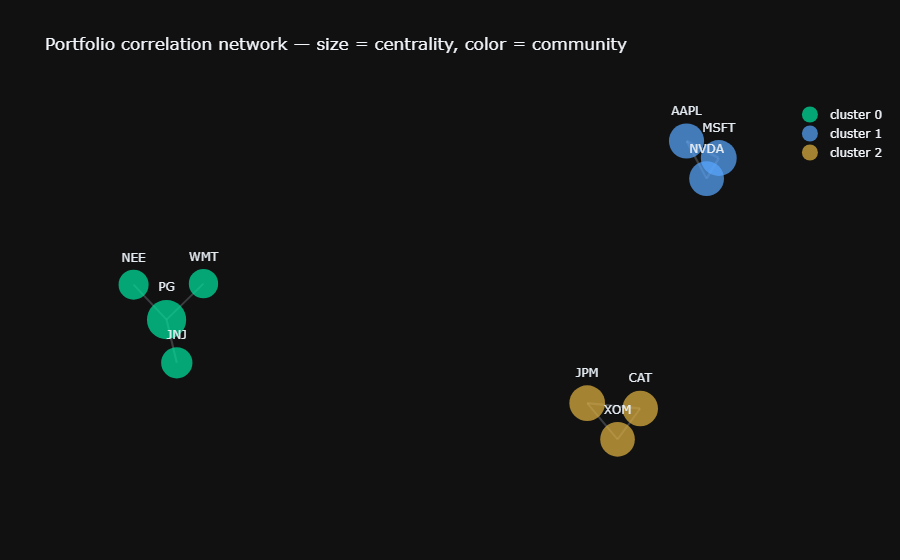

In [2]:
fig = go.Figure()
# edges first (drawn under nodes); width scales with correlation strength
for e in payload["edges"]:
    a, b = nodes.loc[e["source"]], nodes.loc[e["target"]]
    fig.add_scatter(x=[a["x"], b["x"]], y=[a["y"], b["y"]], mode="lines",
                    line=dict(width=4 * e["weight"], color=MUTED),
                    opacity=0.35, hoverinfo="skip", showlegend=False)
for cluster, grp in nodes.groupby("cluster"):
    fig.add_scatter(
        x=grp["x"], y=grp["y"], mode="markers+text", text=grp.index,
        textposition="top center", name=f"cluster {cluster}",
        textfont=dict(size=12, color="#E6EDF3"),
        marker=dict(size=18 + 30 * grp["centrality"],
                    color=CLUSTER_COLORS[cluster % len(CLUSTER_COLORS)],
                    line=dict(width=grp["anomalous"].map({True: 3, False: 0}),
                              color=MINT)))
fig.update_layout(title="Portfolio correlation network — size = centrality, color = community",
                  height=560, width=900, xaxis_visible=False, yaxis_visible=False)
fig.show()

In [3]:
nodes[["centrality", "cluster", "shift_z", "anomalous"]].sort_values(
    "centrality", ascending=False)

,centrality,cluster,shift_z,anomalous
id,,,,
PG,0.7071,0,-0.97,False
MSFT,0.5964,1,1.72,False
JPM,0.5907,2,0.21,False
CAT,0.5852,2,0.44,False
AAPL,0.5726,1,-0.07,False
NVDA,0.5626,1,0.59,False
XOM,0.5555,2,1.14,False
JNJ,0.4431,0,-0.89,False
NEE,0.4014,0,-0.91,False


The communities recover the economy's actual structure from prices alone:
**tech** (AAPL/MSFT/NVDA), **cyclicals** (JPM/CAT/XOM), **defensives**
(PG/JNJ/NEE/WMT). Centrality says the cyclical/tech blocks are where systemic
risk concentrates; WMT and NEE are the most peripheral holdings — the true
diversifiers.

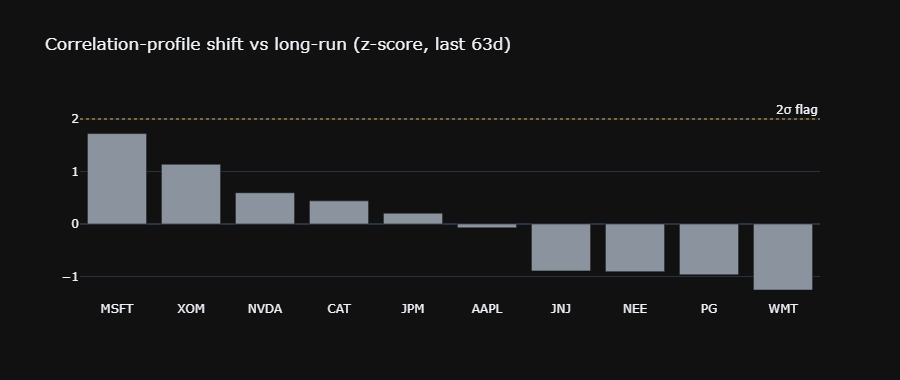

In [4]:
# Correlation-profile drift: whose relationships changed recently?
shifts = correlation_shift(returns).sort_values("zscore", ascending=False)
fig = go.Figure(go.Bar(
    x=shifts.index, y=shifts["zscore"],
    marker_color=[MINT if f else MUTED for f in shifts["flag"]]))
fig.add_hline(y=2.0, line=dict(color=AMBER, dash="dot", width=1),
              annotation_text="2σ flag")
fig.update_layout(title="Correlation-profile shift vs long-run (z-score, last 63d)",
                  height=380, width=900)
fig.show()

## 2 · Stress testing

Historical-simulation stress tests: replay the full history with a scenario's
shocks in force, recompute portfolio risk. Scenarios (see `src/models/stress.py`):

| scenario | story | knobs |
|---|---|---|
| `rate_shock` | aggressive hiking cycle | vol ×1.3; utilities/growth-tech drift down, banks up |
| `market_crash_2008_style` | systemic crash | vol ×2.5; −0.2%/day everywhere (≈ −40%/yr) |
| `sector_shock_tech` | AI unwind | vol ×1.4; heavy drift on NVDA/AAPL/MSFT |

In [5]:
table = compare(returns)
table.style.format({"ann_return": "{:.1%}", "ann_vol": "{:.1%}",
                    "var_95": "{:.2%}", "max_drawdown": "{:.1%}"})

,ann_return,ann_vol,var_95,max_drawdown
scenario,,,,
baseline,22.9%,18.7%,1.69%,-30.0%
rate_shock,13.8%,24.3%,2.26%,-38.8%
market_crash_2008_style,-27.5%,46.7%,4.56%,-97.1%
sector_shock_tech,5.3%,26.2%,2.47%,-49.2%


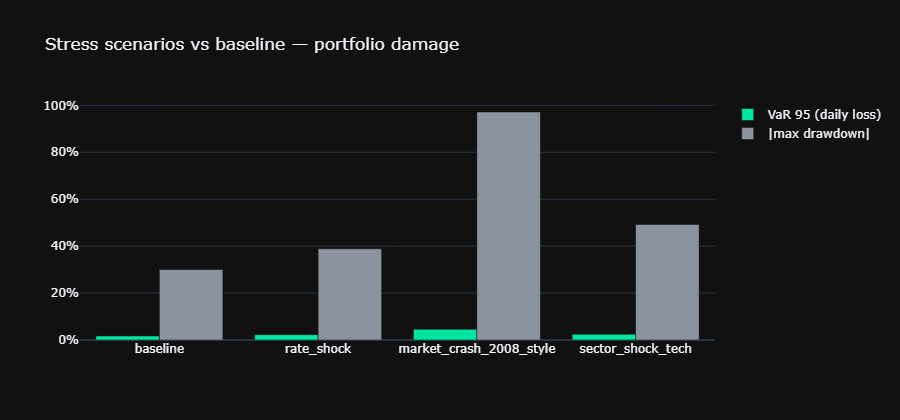

In [6]:
# Before/after damage chart: VaR95 and max drawdown per scenario.
t = table.reset_index()
fig = go.Figure()
fig.add_bar(x=t["scenario"], y=t["var_95"], name="VaR 95 (daily loss)",
            marker_color=MINT)
fig.add_bar(x=t["scenario"], y=t["max_drawdown"].abs(), name="|max drawdown|",
            marker_color=MUTED)
fig.update_layout(barmode="group", height=420, width=900,
                  title="Stress scenarios vs baseline — portfolio damage",
                  yaxis_tickformat=".0%")
fig.show()

## Key findings

1. **The network recovers sectors from prices alone.** Greedy-modularity
   communities on daily-return correlations split the book cleanly into
   tech / cyclicals / defensives — no labels provided. That's a strong check
   that the correlation structure is real signal, not noise.

2. **Systemic importance ≠ biggest position.** Eigenvector centrality puts the
   tech and cyclical blocks at the core of the graph; WMT and NEE sit at the
   periphery. If contagion hits, it propagates through the core — the periphery
   is where the diversification actually lives.

3. **No correlation-regime anomalies right now.** The largest 63-day profile
   shift (MSFT, z≈1.7) stays under the 2σ flag — relationships are currently
   stable. This detector earns its keep in regime breaks, when a defensive
   name starts trading like tech *before* vol shows it.

4. **The crash scenario is the only existential one.** Rate and tech shocks
   roughly double daily VaR (1.7% → ~2.3–2.5%) and deepen the worst drawdown to
   ~-39%/-49% — painful but survivable. The 2008-style scenario (vol ×2.5,
   −0.2%/day) produces a **-97% drawdown**: with these shocks persisted for the
   whole history, the portfolio would effectively not survive. Diversification
   across sectors is no defense when correlations go to one and everything
   drifts down together — the classic systemic-risk lesson.

**Next (Session 3):** the GenAI agent — a memo writer with tool access to
everything computed so far.